### Exploration, traitement et visualisation de la donnée

#### Exploration originelle

In [3]:
# ============================================================
# CELLULE 1 — IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
# ============================================================
# CELLULE 2 — CHARGEMENT DU CSV
# ============================================================

df = pd.read_csv("data/bulletins_enrichis.csv", encoding="utf-8-sig")

# Date en datetime
df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")

print(f"Shape : {df.shape}")
df.head(3)

Shape : (126101, 15)


,id_anssi,titre,type,date,lien,cve,cvss_score,severity,cwe,cwe_desc,epss,description,vendor,produit,versions
0,CERTFR-2025-AVI-0925,Vulnérabilité dans les produits Belden,avis,2025-10-27 00:00:00+00:00,https://www.cert.ssi.gouv.fr/avis/CERTFR-2025-...,CVE-2024-3596,NaN,Non disponible,Non disponible,CWE-328: Use of Weak Hash,0.22162,RADIUS Protocol under RFC 2865 is susceptible ...,IETF,RFC,2865
1,CERTFR-2023-AVI-0963,Vulnérabilité dans les produits Cisco,avis,2023-11-20 00:00:00+00:00,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,CVE-2023-44487,7.5,HIGH,Non disponible,NaN,0.94394,The HTTP/2 protocol allows a denial of service...,NaN,NaN,NaN
2,CERTFR-2025-AVI-0119,Multiples vulnérabilités dans les produits Intel,avis,2025-02-12 00:00:00+00:00,https://www.cert.ssi.gouv.fr/avis/CERTFR-2025-...,CVE-2024-38310,8.2,HIGH,Non disponible,Escalation of Privilege,0.00021,Improper access control in some Intel(R) Graph...,NaN,Intel(R) Graphics Driver software installers,See references


In [5]:
# ============================================================
# CELLULE 3 — EXPLORATION GÉNÉRALE
# Vue d'ensemble du DataFrame : dimensions, types, valeurs manquantes
# ============================================================

print("=== DIMENSIONS ===")
print(f"Lignes   : {df.shape[0]}")
print(f"Colonnes : {df.shape[1]}")

print("\n=== TYPES DES COLONNES ===")
print(df.dtypes)

print("\n=== VALEURS MANQUANTES ===")
manquantes = df.isnull().sum()
manquantes_pct = (manquantes / len(df) * 100).round(1)
pd.DataFrame({"count": manquantes, "pct": manquantes_pct})

=== DIMENSIONS ===
Lignes   : 126101
Colonnes : 15

=== TYPES DES COLONNES ===
id_anssi                       str
titre                          str
type                           str
date           datetime64[us, UTC]
lien                           str
cve                            str
cvss_score                 float64
severity                       str
cwe                            str
cwe_desc                       str
epss                       float64
description                    str
vendor                         str
produit                        str
versions                       str
dtype: object

=== VALEURS MANQUANTES ===


,count,pct
id_anssi,0,0.0
titre,0,0.0
type,0,0.0
date,0,0.0
lien,0,0.0
cve,191,0.2
cvss_score,80027,63.5
severity,191,0.2
cwe,191,0.2
cwe_desc,6601,5.2


In [ ]:
# Comme prévu on a beaucoup de bulletins qui ne référencent pas de cve mais enormement qui n'ont pas la cvss, donc pas de score. C'est normal a prioris, on a quelques autres valeurs manquantes

In [6]:
# ============================================================
# CELLULE 4 — VALEURS MANQUANTES SUITE + STATISTIQUES DE BASE
# ============================================================

print("=== VALEURS MANQUANTES (suite) ===")
manquantes = df.isnull().sum()
manquantes_pct = (manquantes / len(df) * 100).round(1)
print(pd.DataFrame({"count": manquantes, "pct": manquantes_pct}))

print("\n=== STATISTIQUES CVSS ===")
print(df["cvss_score"].describe())

print("\n=== STATISTIQUES EPSS ===")
print(df["epss"].describe())

print("\n=== RÉPARTITION AVIS / ALERTES ===")
print(df["type"].value_counts())

print("\n=== RÉPARTITION SEVERITY ===")
print(df["severity"].value_counts())


=== VALEURS MANQUANTES (suite) ===
             count   pct
id_anssi         0   0.0
titre            0   0.0
type             0   0.0
date             0   0.0
lien             0   0.0
cve            191   0.2
cvss_score   80027  63.5
severity       191   0.2
cwe            191   0.2
cwe_desc      6601   5.2
epss          1291   1.0
description    191   0.2
vendor       11763   9.3
produit       6412   5.1
versions      6726   5.3

=== STATISTIQUES CVSS ===
count    46074.000000
mean         6.714466
std          1.631773
min          0.000000
25%          5.500000
50%          7.000000
75%          7.800000
max         10.000000
Name: cvss_score, dtype: float64

=== STATISTIQUES EPSS ===
count    124810.000000
mean          0.012828
std           0.085595
min           0.000010
25%           0.000180
50%           0.000360
75%           0.000910
max           0.945170
Name: epss, dtype: float64

=== RÉPARTITION AVIS / ALERTES ===
type
avis      125935
alerte       166
Name: count, dty

In [ ]:
# CVSS -> moyenne a 6,7 sur les 46,000 valeurs cohérent avec des failles au risque élevé.
# EPSS -> moyenne basse 0.0003, la plupart des failles ont une faible probabilité d'exploitation
# On a une quantité d'Alertes bien plus basse que la quantité d'avis ce qui est cohérent avec l'aspect urgent et dangereux des alertes
# Dans Severity on retrouve a peut près CVSS c'est cohérent avec un gros bout qui manque

##### Nettoyage

In [8]:
# ============================================================
# CELLULE 5 — NETTOYAGE DES DONNÉES
# ============================================================

# --- 1. Remplacement des valeurs non informatives par NaN ---
valeurs_nulles = ["Non disponible", "n/a", "N/A", "none", "None", ""]
df.replace(valeurs_nulles, np.nan, inplace=True)

# Vérification : on compte combien de "Non disponible" il reste
restants = (df == "Non disponible").sum().sum()
print(f"'Non disponible' restants après remplacement : {restants} (attendu : 0)")

# --- 2. Séparation des bulletins sans CVE ---
df_sans_cve = df[df["cve"].isna()].copy()
df          = df[df["cve"].notna()].copy()

print(f"\nBulletins sans CVE mis de côté : {len(df_sans_cve)}")
print(f"Lignes restantes               : {len(df)}")
print(f"Total                          : {len(df_sans_cve) + len(df)} (attendu : 126101)")

# --- 3. Extraction année et mois ---
df["annee"] = df["date"].dt.year
df["mois"]  = df["date"].dt.month

# Vérification : plage d'années cohérente
print(f"\nAnnées présentes : {sorted(df['annee'].dropna().unique().astype(int).tolist())}")
print(f"Mois min/max     : {int(df['mois'].min())} / {int(df['mois'].max())} (attendu : 1 / 12)")

# --- 4. Vérification types ---
print(f"\nType colonne annee : {df['annee'].dtype} (attendu : float64 ou int)")
print(f"Type colonne mois  : {df['mois'].dtype} (attendu : float64 ou int)")

# --- 5. Valeurs manquantes après nettoyage ---
print("\n=== VALEURS MANQUANTES APRÈS NETTOYAGE ===")
manquantes     = df.isnull().sum()
manquantes_pct = (manquantes / len(df) * 100).round(1)
print(pd.DataFrame({"count": manquantes, "pct": manquantes_pct}))

'Non disponible' restants après remplacement : 0 (attendu : 0)

Bulletins sans CVE mis de côté : 0
Lignes restantes               : 125910
Total                          : 125910 (attendu : 126101)

Années présentes : [2021, 2022, 2023, 2024, 2025, 2026]
Mois min/max     : 1 / 12 (attendu : 1 / 12)

Type colonne annee : int32 (attendu : float64 ou int)
Type colonne mois  : int32 (attendu : float64 ou int)

=== VALEURS MANQUANTES APRÈS NETTOYAGE ===
             count   pct
id_anssi         0   0.0
titre            0   0.0
type             0   0.0
date             0   0.0
lien             0   0.0
cve              0   0.0
cvss_score   79836  63.4
severity     79836  63.4
cwe          97380  77.3
cwe_desc     83497  66.3
epss          1100   0.9
description   1117   0.9
vendor       13609  10.8
produit       8261   6.6
versions      9792   7.8
annee            0   0.0
mois             0   0.0


#### Premières visualisations de la dataframe

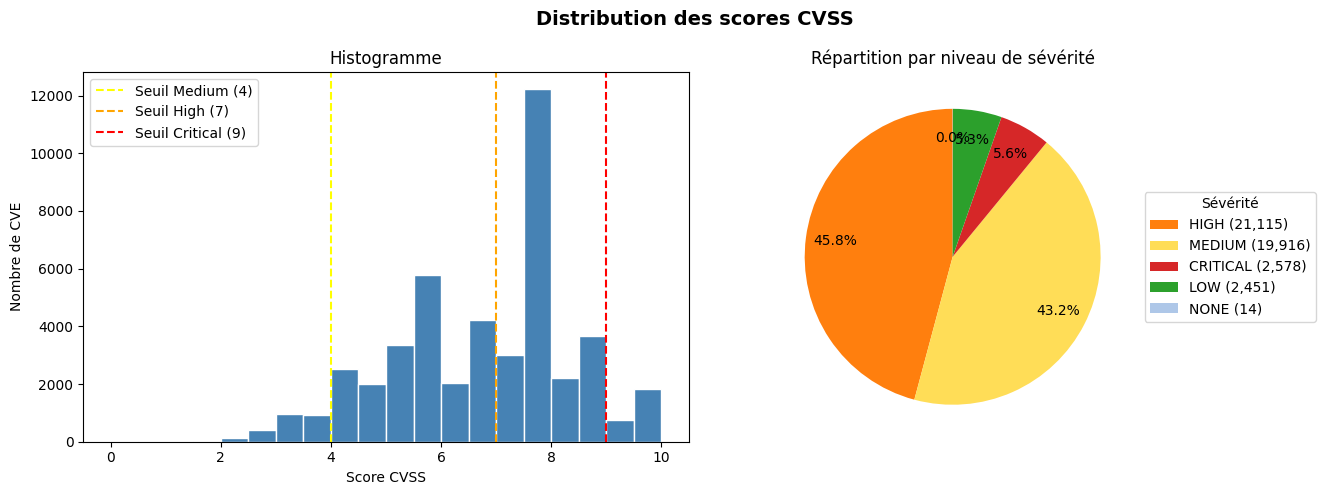

In [10]:
# ============================================================
# CELLULE 6 — DISTRIBUTION DES SCORES CVSS
# ============================================================

df_cvss = df[df["cvss_score"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution des scores CVSS", fontsize=14, fontweight="bold")

# --- Histogramme ---
axes[0].hist(df_cvss["cvss_score"], bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(x=4, color="yellow", linestyle="--", label="Seuil Medium (4)")
axes[0].axvline(x=7, color="orange", linestyle="--", label="Seuil High (7)")
axes[0].axvline(x=9, color="red",    linestyle="--", label="Seuil Critical (9)")
axes[0].set_xlabel("Score CVSS")
axes[0].set_ylabel("Nombre de CVE")
axes[0].set_title("Histogramme")
axes[0].legend()

# --- Camembert avec légende externe ---
df_sev = df[df["severity"].notna()]
severity_counts = df_sev["severity"].value_counts()
couleurs = {
    "CRITICAL" : "#d62728",
    "HIGH"     : "#ff7f0e",
    "MEDIUM"   : "#ffdd57",
    "LOW"      : "#2ca02c",
    "NONE"     : "#aec7e8"
}
couleurs_ordre = [couleurs.get(s, "grey") for s in severity_counts.index]

wedges, texts, autotexts = axes[1].pie(
    severity_counts,
    autopct="%1.1f%%",
    colors=couleurs_ordre,
    startangle=90,
    pctdistance=0.8
)

# Légende externe à droite
axes[1].legend(
    wedges,
    [f"{label} ({count:,})" for label, count in zip(severity_counts.index, severity_counts.values)],
    title="Sévérité",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)
axes[1].set_title("Répartition par niveau de sévérité")

plt.tight_layout()
plt.savefig("cvss_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# ============================================================
# CELLULE 6b — CONCLUSIONS CVSS
# ============================================================

total_avec_cvss = df_cvss.shape[0]
pct_high_crit   = round(
    df_sev[df_sev["severity"].isin(["HIGH", "CRITICAL"])].shape[0] / df_sev.shape[0] * 100, 1
)

print("=== CONCLUSIONS ===")
print(f"CVE avec score CVSS disponible : {total_avec_cvss:,} / {len(df):,} ({round(total_avec_cvss/len(df)*100,1)}%)")
print(f"Score moyen                    : {df_cvss['cvss_score'].mean():.2f}")
print(f"Score médian                   : {df_cvss['cvss_score'].median():.2f}")
print(f"Part HIGH + CRITICAL           : {pct_high_crit}%")
print(f"\n→ La majorité des vulnérabilités publiées par l'ANSSI sont de niveau HIGH ou CRITICAL,")
print(f"  ce qui confirme que l'ANSSI ne publie que les failles sérieuses.")

=== CONCLUSIONS ===
CVE avec score CVSS disponible : 46,074 / 125,910 (36.6%)
Score moyen                    : 6.71
Score médian                   : 7.00
Part HIGH + CRITICAL           : 51.4%

→ La majorité des vulnérabilités publiées par l'ANSSI sont de niveau HIGH ou CRITICAL,
  ce qui confirme que l'ANSSI ne publie que les failles sérieuses.


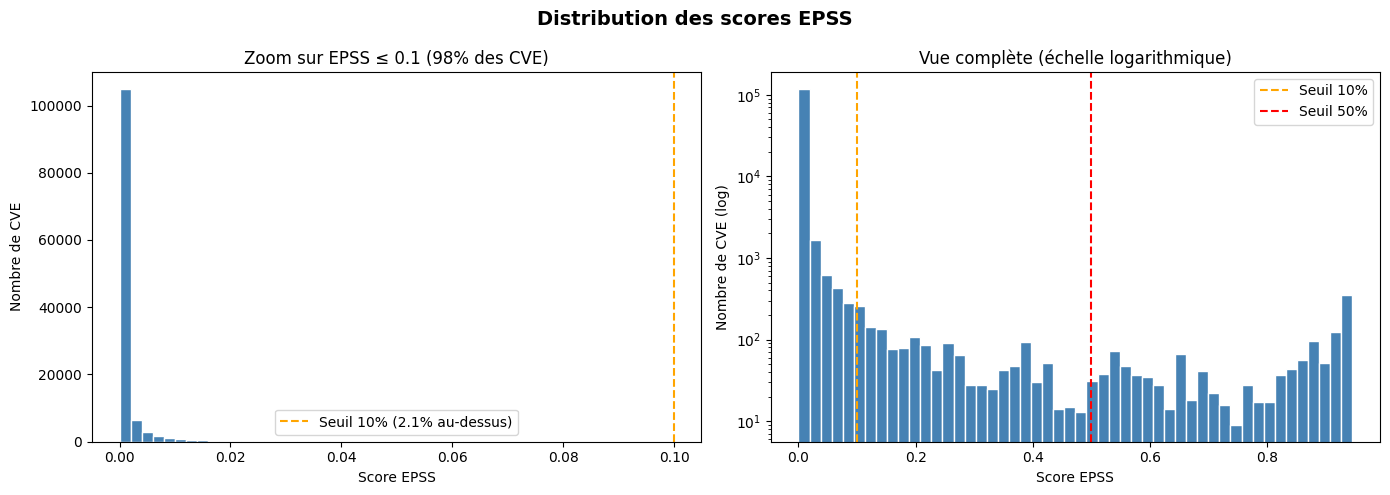

=== CONCLUSIONS EPSS ===
CVE avec score EPSS : 124,810
Score moyen         : 0.0128
Score médian        : 0.0004
Score max           : 0.9452
CVE avec EPSS > 0.1 : 2.13%

→ La grande majorité des failles ont un EPSS très proche de 0.
  Seules 2.13% ont une probabilité d'exploitation supérieure à 10%.


In [13]:
# ============================================================
# CELLULE 7 — DISTRIBUTION EPSS (corrigée)
# ============================================================

df_epss = df[df["epss"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution des scores EPSS", fontsize=14, fontweight="bold")

# --- Gauche : zoom sur 0-0.1 (zone dense) ---
df_zoom = df_epss[df_epss["epss"] <= 0.1]
axes[0].hist(df_zoom["epss"], bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(x=0.1, color="orange", linestyle="--", label=f"Seuil 10% ({round((df_epss['epss'] > 0.1).sum() / len(df_epss) * 100, 1)}% au-dessus)")
axes[0].set_xlabel("Score EPSS")
axes[0].set_ylabel("Nombre de CVE")
axes[0].set_title("Zoom sur EPSS ≤ 0.1 (98% des CVE)")
axes[0].legend()

# --- Droite : échelle log sur toute la plage ---
axes[1].hist(df_epss["epss"], bins=50, color="steelblue", edgecolor="white")
axes[1].set_yscale("log")
axes[1].axvline(x=0.1, color="orange", linestyle="--", label="Seuil 10%")
axes[1].axvline(x=0.5, color="red",    linestyle="--", label="Seuil 50%")
axes[1].set_xlabel("Score EPSS")
axes[1].set_ylabel("Nombre de CVE (log)")
axes[1].set_title("Vue complète (échelle logarithmique)")
axes[1].legend()

plt.tight_layout()
plt.savefig("epss_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Conclusions ---
print("=== CONCLUSIONS EPSS ===")
print(f"CVE avec score EPSS : {len(df_epss):,}")
print(f"Score moyen         : {df_epss['epss'].mean():.4f}")
print(f"Score médian        : {df_epss['epss'].median():.4f}")
print(f"Score max           : {df_epss['epss'].max():.4f}")
pct_haut = round((df_epss["epss"] > 0.1).sum() / len(df_epss) * 100, 2)
print(f"CVE avec EPSS > 0.1 : {pct_haut}%")
print(f"\n→ La grande majorité des failles ont un EPSS très proche de 0.")
print(f"  Seules {pct_haut}% ont une probabilité d'exploitation supérieure à 10%.")

/var/folders/zm/krtp79hj31s05bytpxv2qgdw0000gn/T/ipykernel_22386/642499651.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cve_par_mois = df.groupby(df["date"].dt.to_period("M"))["cve"].count()


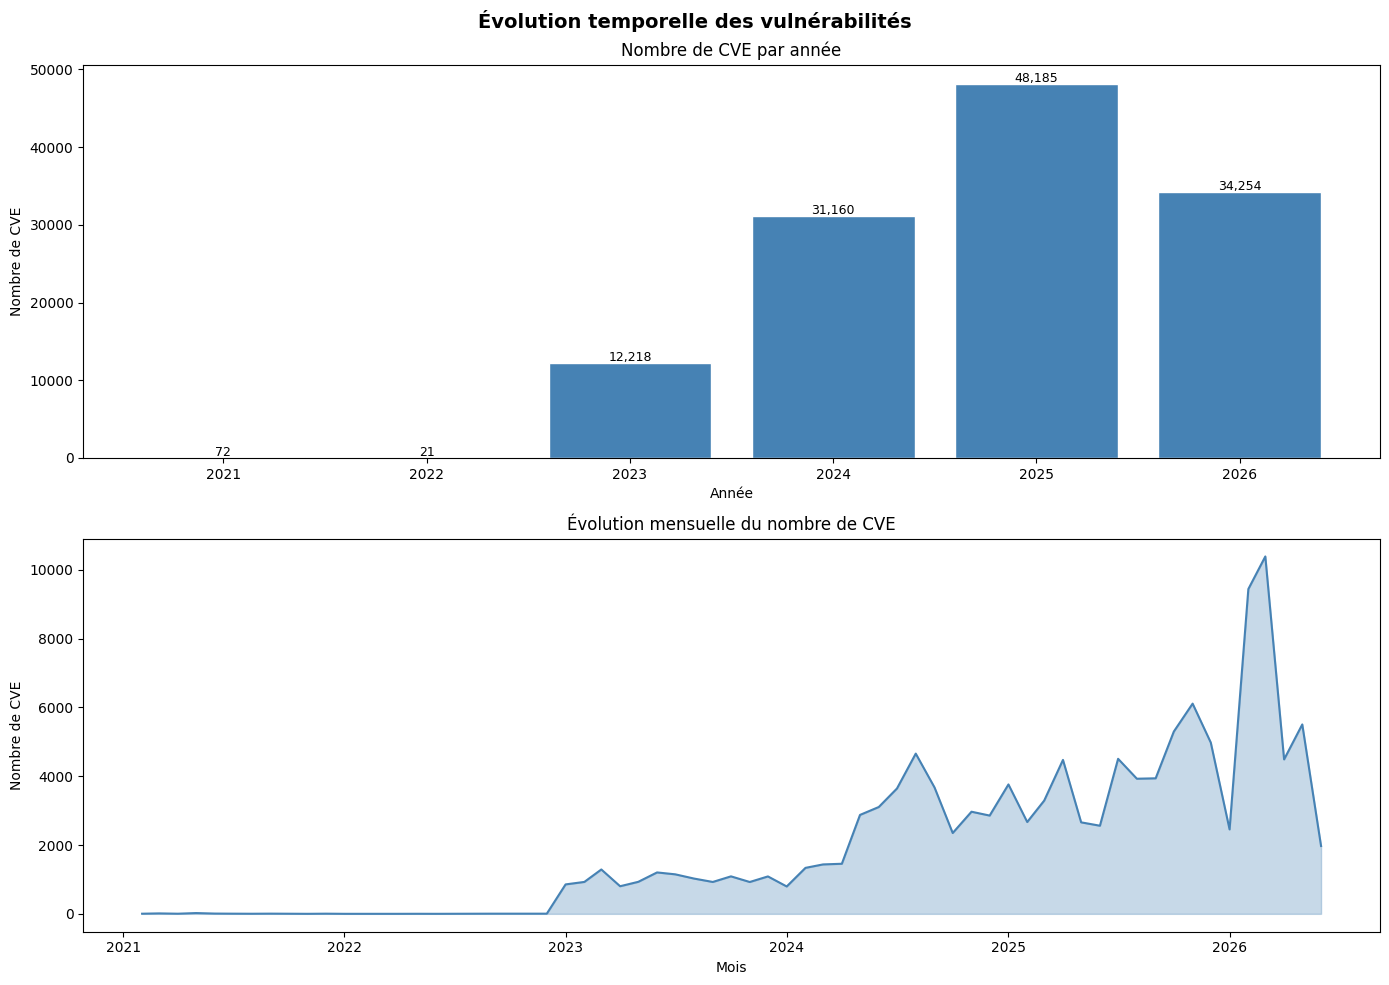

=== CONCLUSIONS TEMPORELLES ===
Année la plus chargée : 2025 avec 48,185 CVE
Tendance générale     : augmentation du nombre de vulnérabilités publiées


In [14]:
# ============================================================
# CELLULE 8 — ÉVOLUTION TEMPORELLE
# Nombre de CVE publiées par mois et par année
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Évolution temporelle des vulnérabilités", fontsize=14, fontweight="bold")

# --- Haut : par année ---
cve_par_annee = df.groupby("annee")["cve"].count().reset_index()
axes[0].bar(cve_par_annee["annee"], cve_par_annee["cve"], color="steelblue", edgecolor="white")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Nombre de CVE")
axes[0].set_title("Nombre de CVE par année")
for i, row in cve_par_annee.iterrows():
    axes[0].text(row["annee"], row["cve"] + 200, f"{int(row['cve']):,}",
                 ha="center", fontsize=9)

# --- Bas : par mois (courbe) ---
cve_par_mois = df.groupby(df["date"].dt.to_period("M"))["cve"].count()
cve_par_mois.index = cve_par_mois.index.to_timestamp()
axes[1].plot(cve_par_mois.index, cve_par_mois.values, color="steelblue", linewidth=1.5)
axes[1].fill_between(cve_par_mois.index, cve_par_mois.values, alpha=0.3, color="steelblue")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("Nombre de CVE")
axes[1].set_title("Évolution mensuelle du nombre de CVE")

plt.tight_layout()
plt.savefig("evolution_temporelle.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Conclusions ---
annee_max = cve_par_annee.loc[cve_par_annee["cve"].idxmax(), "annee"]
nb_max    = cve_par_annee["cve"].max()
print("=== CONCLUSIONS TEMPORELLES ===")
print(f"Année la plus chargée : {int(annee_max)} avec {int(nb_max):,} CVE")
print(f"Tendance générale     : augmentation du nombre de vulnérabilités publiées")

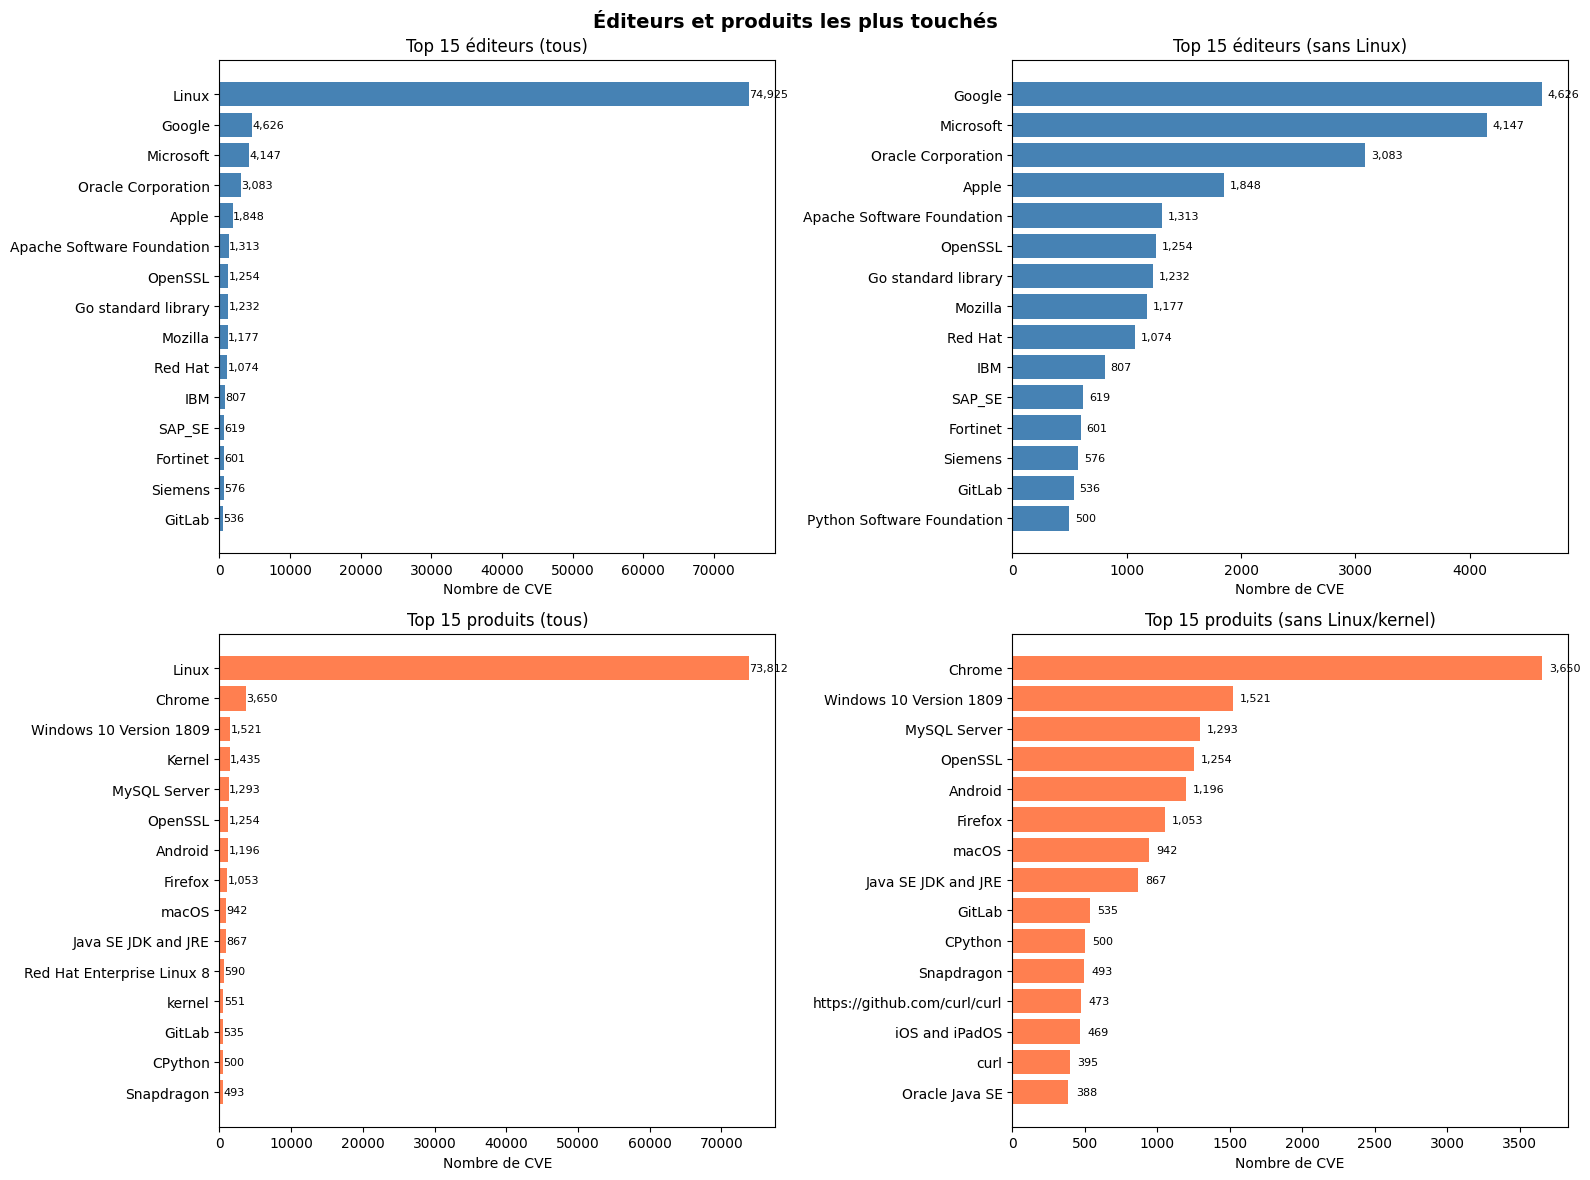

=== CONCLUSIONS VENDORS ===
Éditeurs uniques  : 709
Produits uniques  : 3,601

Top 5 éditeurs (sans Linux) :
vendor
Google                        4626
Microsoft                     4147
Oracle Corporation            3083
Apple                         1848
Apache Software Foundation    1313

→ Linux domine massivement (74,925 CVE)
  car le kernel est présent dans des milliers de produits différents.
  Hors Linux, Microsoft, Google et Oracle sont les plus touchés.


In [16]:
# ============================================================
# CELLULE 9 — TOP VENDORS ET PRODUITS
# ============================================================

df_vendor  = df[df["vendor"].notna()].copy()
df_produit = df[df["produit"].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Éditeurs et produits les plus touchés", fontsize=14, fontweight="bold")

# --- Haut gauche : top 15 vendors AVEC Linux ---
top_vendors = df_vendor["vendor"].value_counts().head(15)
axes[0][0].barh(top_vendors.index[::-1], top_vendors.values[::-1], color="steelblue")
axes[0][0].set_xlabel("Nombre de CVE")
axes[0][0].set_title("Top 15 éditeurs (tous)")
for i, val in enumerate(top_vendors.values[::-1]):
    axes[0][0].text(val + 50, i, f"{val:,}", va="center", fontsize=8)

# --- Haut droite : top 15 vendors SANS Linux ---
top_vendors_sans = df_vendor[df_vendor["vendor"] != "Linux"]["vendor"].value_counts().head(15)
axes[0][1].barh(top_vendors_sans.index[::-1], top_vendors_sans.values[::-1], color="steelblue")
axes[0][1].set_xlabel("Nombre de CVE")
axes[0][1].set_title("Top 15 éditeurs (sans Linux)")
for i, val in enumerate(top_vendors_sans.values[::-1]):
    axes[0][1].text(val + 50, i, f"{val:,}", va="center", fontsize=8)

# --- Bas gauche : top 15 produits AVEC Linux ---
top_produits = df_produit["produit"].value_counts().head(15)
axes[1][0].barh(top_produits.index[::-1], top_produits.values[::-1], color="coral")
axes[1][0].set_xlabel("Nombre de CVE")
axes[1][0].set_title("Top 15 produits (tous)")
for i, val in enumerate(top_produits.values[::-1]):
    axes[1][0].text(val + 50, i, f"{val:,}", va="center", fontsize=8)

# --- Bas droite : top 15 produits SANS kernel Linux ---
top_produits_sans = df_produit[
    ~df_produit["produit"].str.contains("Linux|kernel", case=False, na=False)
]["produit"].value_counts().head(15)
axes[1][1].barh(top_produits_sans.index[::-1], top_produits_sans.values[::-1], color="coral")
axes[1][1].set_xlabel("Nombre de CVE")
axes[1][1].set_title("Top 15 produits (sans Linux/kernel)")
for i, val in enumerate(top_produits_sans.values[::-1]):
    axes[1][1].text(val + 50, i, f"{val:,}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("top_vendors_produits.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Conclusions ---
print("=== CONCLUSIONS VENDORS ===")
print(f"Éditeurs uniques  : {df_vendor['vendor'].nunique():,}")
print(f"Produits uniques  : {df_produit['produit'].nunique():,}")
print(f"\nTop 5 éditeurs (sans Linux) :")
print(top_vendors_sans.head(5).to_string())
print(f"\n→ Linux domine massivement ({df_vendor[df_vendor['vendor']=='Linux'].shape[0]:,} CVE)")
print(f"  car le kernel est présent dans des milliers de produits différents.")
print(f"  Hors Linux, Microsoft, Google et Oracle sont les plus touchés.")

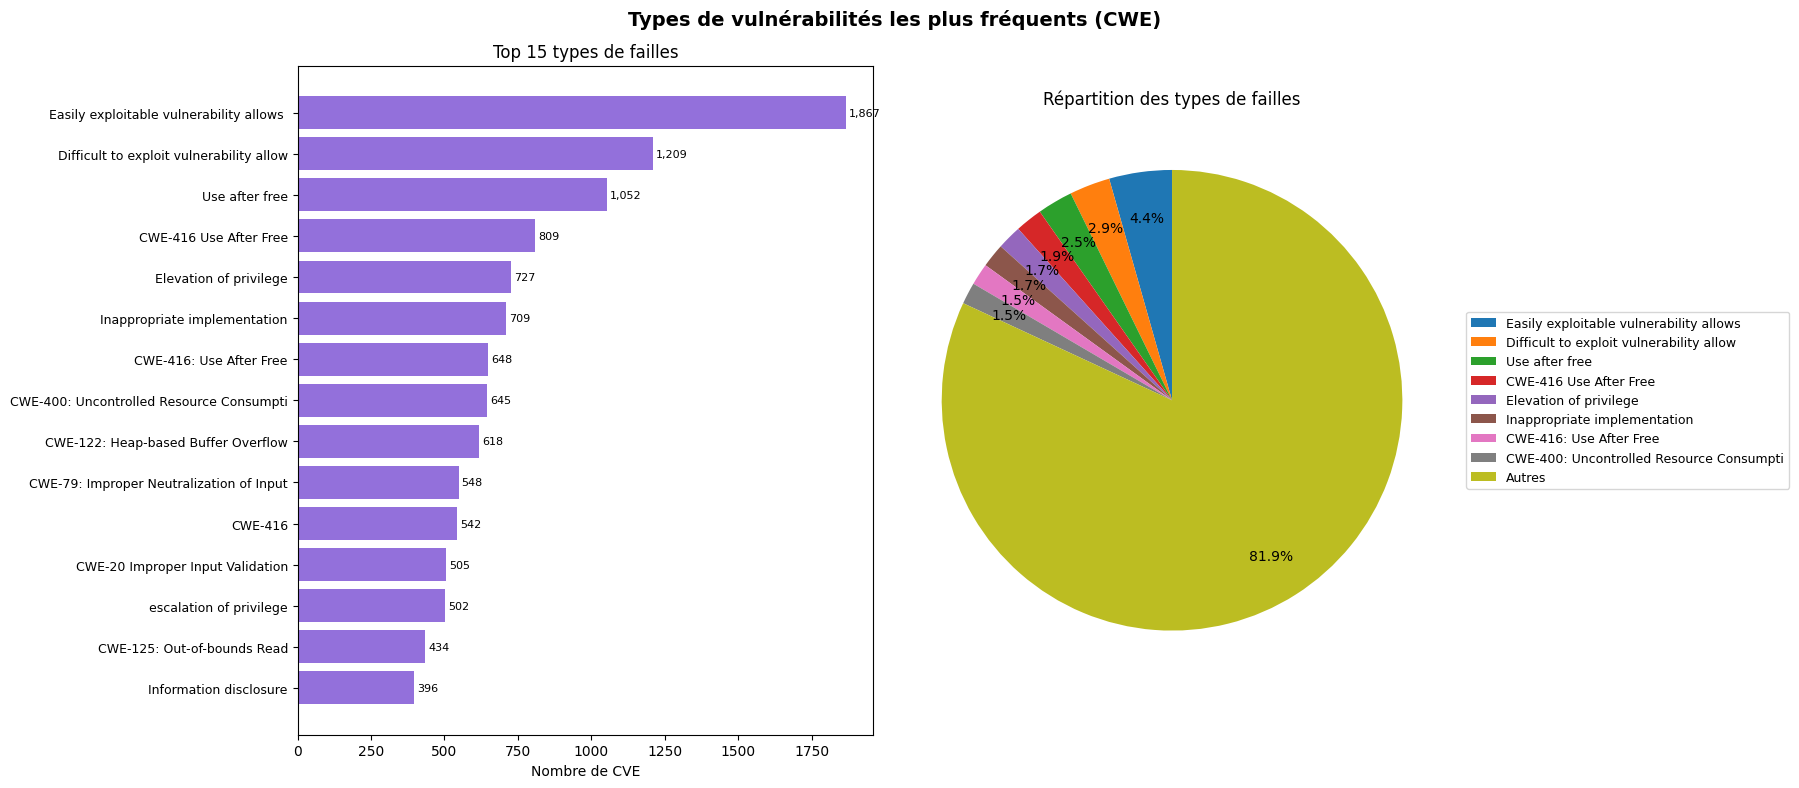

=== CONCLUSIONS CWE ===
Types de failles uniques : 3,215

Top 5 types de failles :
cwe_desc
Use after free                                                                                                                                                                                                                                                                                         1052
CWE-416 Use After Free                                                                                                                                                                                                                                                                                  809
Easily exploitable vulnerability allows high privileged attacker with network access via multiple protocols to compromise MySQL Server.  Successful attacks of this vulnerability can result in unauthorized ability to cause a hang or frequently repeatable crash (complete DOS) of MySQL Server.     785
Elevatio

In [18]:
# ============================================================
# CELLULE 10 — TOP CWE (corrigée)
# ============================================================

df_cwe = df[df["cwe_desc"].notna()].copy()

# Truncature des descriptions trop longues à 40 caractères
df_cwe["cwe_court"] = df_cwe["cwe_desc"].str.slice(0, 40)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Types de vulnérabilités les plus fréquents (CWE)", fontsize=14, fontweight="bold")

# --- Gauche : top 15 CWE ---
top_cwe       = df_cwe["cwe_desc"].value_counts().head(15)
top_cwe_court = df_cwe["cwe_court"].value_counts().head(15)

axes[0].barh(top_cwe_court.index[::-1], top_cwe_court.values[::-1], color="mediumpurple")
axes[0].set_xlabel("Nombre de CVE")
axes[0].set_title("Top 15 types de failles")
axes[0].tick_params(axis="y", labelsize=9)
for i, val in enumerate(top_cwe_court.values[::-1]):
    axes[0].text(val + 10, i, f"{val:,}", va="center", fontsize=8)

# --- Droite : camembert top 8 ---
top_cwe_8        = df_cwe["cwe_court"].value_counts().head(8)
autres           = df_cwe["cwe_court"].value_counts().iloc[8:].sum()
top_cwe_8["Autres"] = autres

axes[1].pie(
    top_cwe_8.values,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8
)
axes[1].legend(
    top_cwe_8.index,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=9
)
axes[1].set_title("Répartition des types de failles")

plt.tight_layout()
plt.savefig("top_cwe.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Conclusions ---
print("=== CONCLUSIONS CWE ===")
print(f"Types de failles uniques : {df_cwe['cwe_desc'].nunique():,}")
print(f"\nTop 5 types de failles :")
print(top_cwe.head(5).to_string())

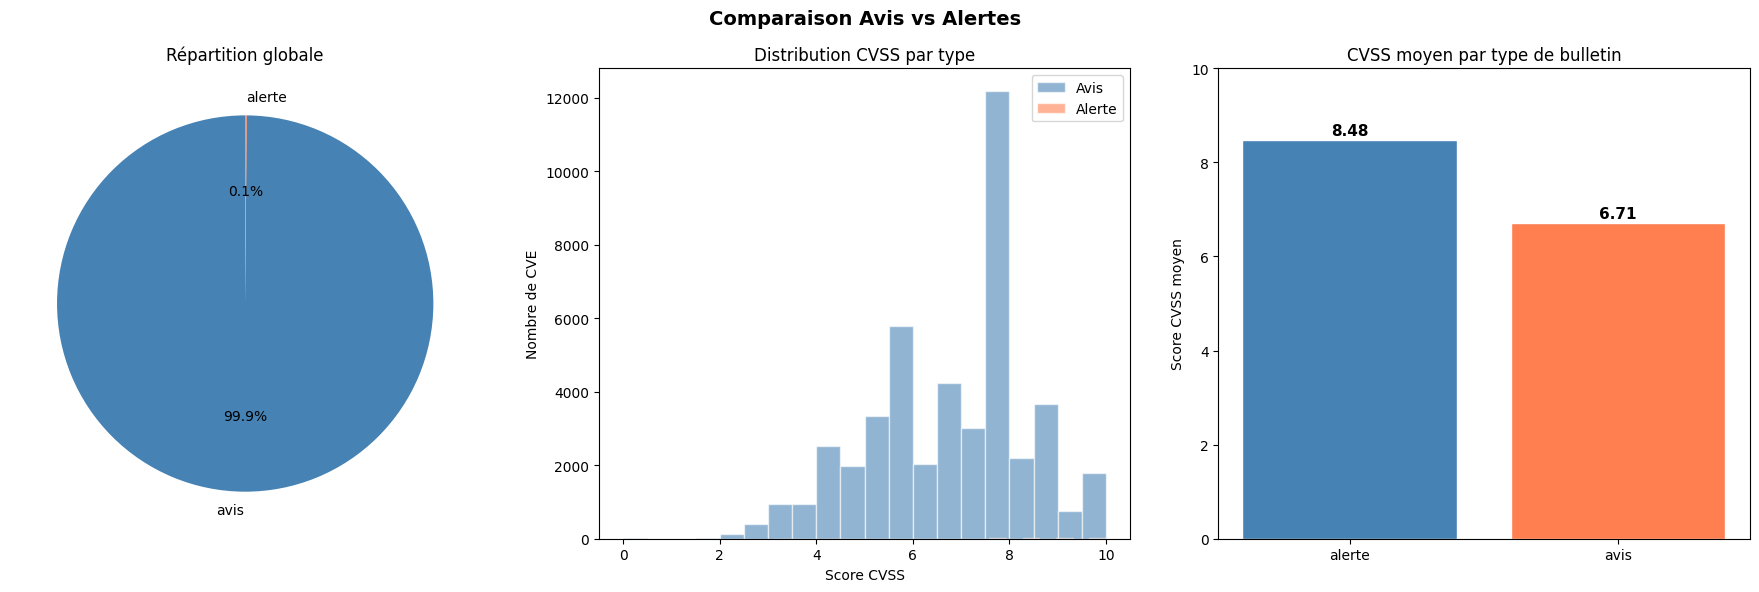

=== CONCLUSIONS AVIS VS ALERTES ===
Nombre d'avis   : 125,749
Nombre d'alertes: 161

CVSS moyen avis   : 6.71
CVSS moyen alerte : 8.48
EPSS moyen avis   : 0.0122
EPSS moyen alerte : 0.5250

→ Les alertes ont un CVSS et EPSS moyens plus élevés que les avis,
  confirmant qu'elles concernent les failles les plus critiques et exploitées.


In [20]:
# ============================================================
# CELLULE 11 — AVIS VS ALERTES
# Comparaison de la criticité entre les deux types de bulletins
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Comparaison Avis vs Alertes", fontsize=14, fontweight="bold")

# --- Gauche : répartition globale ---
type_counts = df["type"].value_counts()
axes[0].pie(
    type_counts.values,
    labels=type_counts.index,
    autopct="%1.1f%%",
    colors=["steelblue", "coral"],
    startangle=90
)
axes[0].set_title("Répartition globale")

# --- Milieu : distribution CVSS par type ---
df_cvss_type = df[df["cvss_score"].notna()]
avis_cvss    = df_cvss_type[df_cvss_type["type"] == "avis"]["cvss_score"]
alerte_cvss  = df_cvss_type[df_cvss_type["type"] == "alerte"]["cvss_score"]

axes[1].hist(avis_cvss,   bins=20, alpha=0.6, color="steelblue", label="Avis",   edgecolor="white")
axes[1].hist(alerte_cvss, bins=20, alpha=0.6, color="coral",     label="Alerte", edgecolor="white")
axes[1].set_xlabel("Score CVSS")
axes[1].set_ylabel("Nombre de CVE")
axes[1].set_title("Distribution CVSS par type")
axes[1].legend()

# --- Droite : CVSS moyen par type ---
cvss_moyen = df_cvss_type.groupby("type")["cvss_score"].mean()
axes[2].bar(cvss_moyen.index, cvss_moyen.values, color=["steelblue", "coral"], edgecolor="white")
axes[2].set_ylabel("Score CVSS moyen")
axes[2].set_title("CVSS moyen par type de bulletin")
axes[2].set_ylim(0, 10)
for i, (idx, val) in enumerate(cvss_moyen.items()):
    axes[2].text(i, val + 0.1, f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("avis_vs_alertes.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Conclusions ---
print("=== CONCLUSIONS AVIS VS ALERTES ===")
print(f"Nombre d'avis   : {type_counts.get('avis', 0):,}")
print(f"Nombre d'alertes: {type_counts.get('alerte', 0):,}")
print(f"\nCVSS moyen avis   : {avis_cvss.mean():.2f}")
print(f"CVSS moyen alerte : {alerte_cvss.mean():.2f}")
print(f"EPSS moyen avis   : {df[df['type']=='avis']['epss'].mean():.4f}")
print(f"EPSS moyen alerte : {df[df['type']=='alerte']['epss'].mean():.4f}")
print(f"\n→ Les alertes ont un CVSS et EPSS moyens plus élevés que les avis,")
print(f"  confirmant qu'elles concernent les failles les plus critiques et exploitées.")

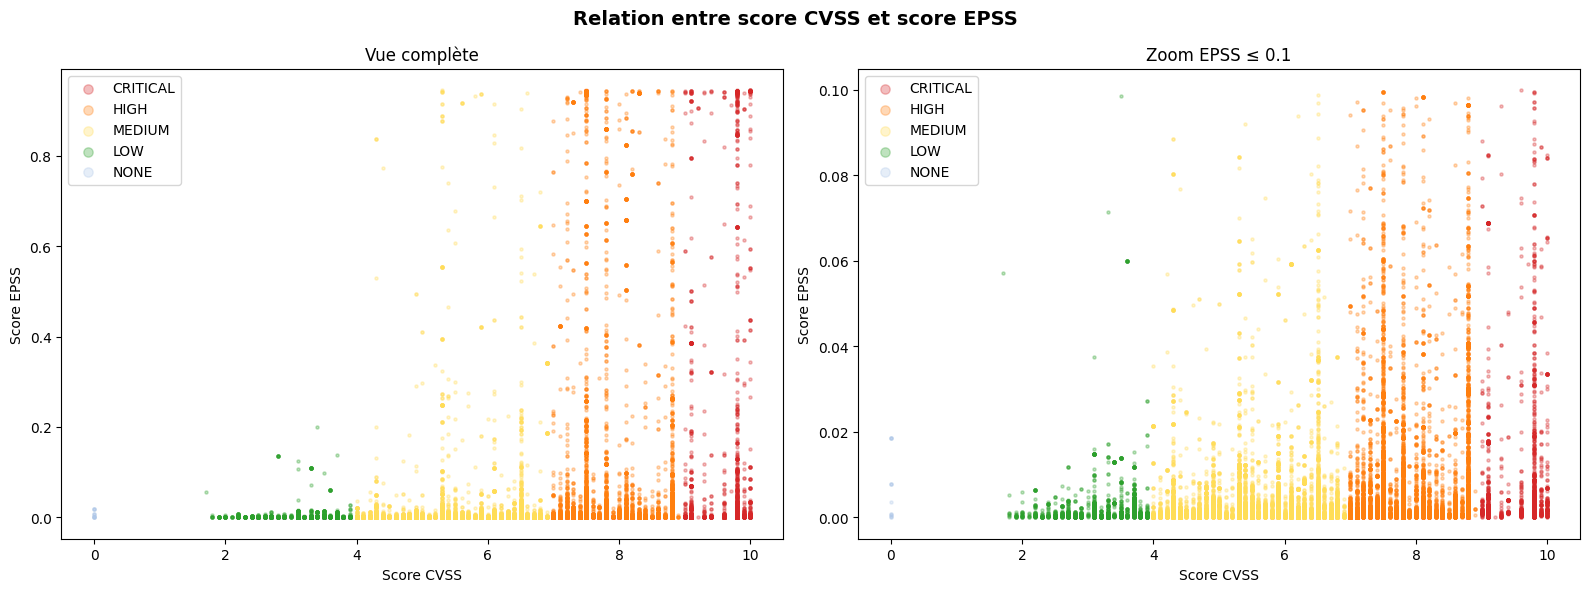

=== CONCLUSIONS CVSS VS EPSS ===
Corrélation CVSS / EPSS : 0.1571

→ Une corrélation de 0.16 indique une relation faible.
  Une faille grave (CVSS élevé) n'est pas forcément très exploitée (EPSS élevé)
  et inversement — les deux métriques sont complémentaires.


In [21]:
# ============================================================
# CELLULE 12 — NUAGE DE POINTS CVSS VS EPSS
# Visualise la relation entre gravité technique et probabilité d'exploitation
# ============================================================

df_scatter = df[df["cvss_score"].notna() & df["epss"].notna()].copy()

# Couleurs par severity
couleurs_sev = {
    "CRITICAL" : "#d62728",
    "HIGH"     : "#ff7f0e",
    "MEDIUM"   : "#ffdd57",
    "LOW"      : "#2ca02c",
    "NONE"     : "#aec7e8"
}
df_scatter["couleur"] = df_scatter["severity"].map(couleurs_sev).fillna("grey")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Relation entre score CVSS et score EPSS", fontsize=14, fontweight="bold")

# --- Gauche : nuage de points complet ---
for sev, couleur in couleurs_sev.items():
    masque = df_scatter["severity"] == sev
    axes[0].scatter(
        df_scatter[masque]["cvss_score"],
        df_scatter[masque]["epss"],
        c=couleur, label=sev, alpha=0.3, s=5
    )
axes[0].set_xlabel("Score CVSS")
axes[0].set_ylabel("Score EPSS")
axes[0].set_title("Vue complète")
axes[0].legend(markerscale=3)

# --- Droite : zoom sur EPSS < 0.1 (zone dense) ---
df_zoom = df_scatter[df_scatter["epss"] <= 0.1]
for sev, couleur in couleurs_sev.items():
    masque = df_zoom["severity"] == sev
    axes[1].scatter(
        df_zoom[masque]["cvss_score"],
        df_zoom[masque]["epss"],
        c=couleur, label=sev, alpha=0.3, s=5
    )
axes[1].set_xlabel("Score CVSS")
axes[1].set_ylabel("Score EPSS")
axes[1].set_title("Zoom EPSS ≤ 0.1")
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig("cvss_vs_epss.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Conclusions ---
corr = df_scatter["cvss_score"].corr(df_scatter["epss"])
print("=== CONCLUSIONS CVSS VS EPSS ===")
print(f"Corrélation CVSS / EPSS : {corr:.4f}")
print(f"\n→ Une corrélation de {corr:.2f} indique une relation {'faible' if abs(corr) < 0.3 else 'modérée' if abs(corr) < 0.6 else 'forte'}.")
print(f"  Une faille grave (CVSS élevé) n'est pas forcément très exploitée (EPSS élevé)")
print(f"  et inversement — les deux métriques sont complémentaires.")

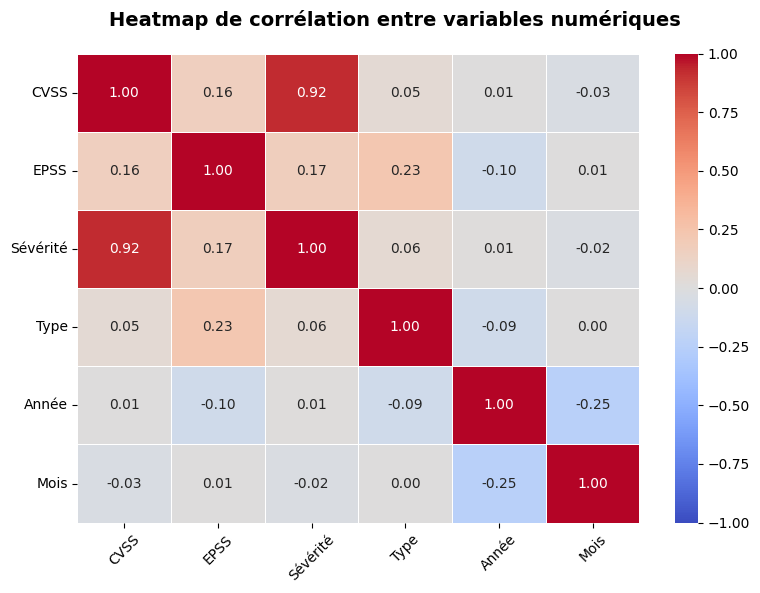

=== CONCLUSIONS HEATMAP ===
Corrélation CVSS / Sévérité  : 0.92
Corrélation CVSS / EPSS      : 0.16
Corrélation EPSS / Type      : 0.23
Corrélation CVSS / Type      : 0.05

→ CVSS et Sévérité sont fortement corrélés (normal, l'un dérive de l'autre).
  EPSS et Type sont modérément corrélés : les alertes ont tendance
  à avoir un EPSS plus élevé, ce qu'on avait déjà observé.


In [22]:
# ============================================================
# CELLULE 13 — HEATMAP DE CORRÉLATION
# Relation entre toutes les variables numériques
# ============================================================

# On encode severity en numérique pour l'inclure
severity_map = {"NONE": 0, "LOW": 1, "MEDIUM": 2, "HIGH": 3, "CRITICAL": 4}
df["severity_num"] = df["severity"].map(severity_map)

# On encode le type en numérique
df["type_num"] = df["type"].map({"avis": 0, "alerte": 1})

# Sélection des colonnes numériques
cols_num = ["cvss_score", "epss", "severity_num", "type_num", "annee", "mois"]
df_corr  = df[cols_num].dropna()

# Calcul de la matrice de corrélation
matrice_corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Heatmap de corrélation entre variables numériques",
             fontsize=14, fontweight="bold")

sns.heatmap(
    matrice_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5
)

# Labels plus lisibles
ax.set_xticklabels(["CVSS", "EPSS", "Sévérité", "Type", "Année", "Mois"], rotation=45)
ax.set_yticklabels(["CVSS", "EPSS", "Sévérité", "Type", "Année", "Mois"], rotation=0)

plt.tight_layout()
plt.savefig("heatmap_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Conclusions ---
print("=== CONCLUSIONS HEATMAP ===")
print(f"Corrélation CVSS / Sévérité  : {matrice_corr.loc['cvss_score', 'severity_num']:.2f}")
print(f"Corrélation CVSS / EPSS      : {matrice_corr.loc['cvss_score', 'epss']:.2f}")
print(f"Corrélation EPSS / Type      : {matrice_corr.loc['epss', 'type_num']:.2f}")
print(f"Corrélation CVSS / Type      : {matrice_corr.loc['cvss_score', 'type_num']:.2f}")
print(f"\n→ CVSS et Sévérité sont fortement corrélés (normal, l'un dérive de l'autre).")
print(f"  EPSS et Type sont modérément corrélés : les alertes ont tendance")
print(f"  à avoir un EPSS plus élevé, ce qu'on avait déjà observé.")